In [1]:
from py_files.setup import *
setup_notebook()

import py_files.inverse_leontif_NX as il_NX

# `GG-B`-like labour shares

*`1. plot differential`*

In [2]:
# 1. get Leontif inverse values
years = range(1966, 2024)
df_ts = sls.compute_sectoral_ls_timeseries(years, kappa=0.6)

Fetching industry labor shares from NABP36 ...
Processing year 1966...
  1966:  LS_C=0.533  LS_I=0.607  Δ=0.074
Processing year 1967...
  1967:  LS_C=0.533  LS_I=0.613  Δ=0.080
Processing year 1968...
  1968:  LS_C=0.538  LS_I=0.628  Δ=0.090
Processing year 1969...
  1969:  LS_C=0.532  LS_I=0.638  Δ=0.105
Processing year 1970...
  1970:  LS_C=0.542  LS_I=0.645  Δ=0.102
Processing year 1971...
  1971:  LS_C=0.554  LS_I=0.645  Δ=0.091
Processing year 1972...
  1972:  LS_C=0.550  LS_I=0.618  Δ=0.068
Processing year 1973...
  1973:  LS_C=0.539  LS_I=0.627  Δ=0.087
Processing year 1974...
  1974:  LS_C=0.563  LS_I=0.651  Δ=0.088
Processing year 1975...
  1975:  LS_C=0.569  LS_I=0.635  Δ=0.065
Processing year 1976...
  1976:  LS_C=0.565  LS_I=0.646  Δ=0.081
Processing year 1977...
  1977:  LS_C=0.570  LS_I=0.648  Δ=0.078
Processing year 1978...
  1978:  LS_C=0.570  LS_I=0.657  Δ=0.087
Processing year 1979...
  1979:  LS_C=0.573  LS_I=0.679  Δ=0.106
Processing year 1980...
  1980:  LS_C=0.616

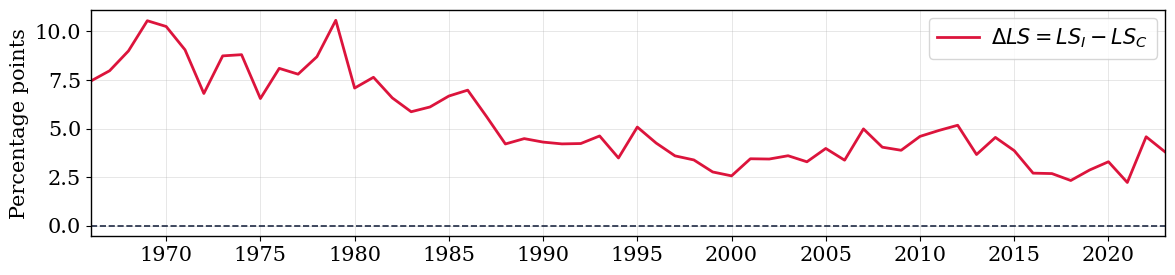

(<Figure size 1200x300 with 1 Axes>, <Axes: ylabel='Percentage points'>)

In [3]:
# 2. plot the difference between sectors
sls.plot_ls_difference(df_ts)

*`2. inspect and sanity`*

In [8]:
# 4. inspect industrylevel
diag = sls.inspect_year(2020)
diag[['direct_ls', 'consolidated_ls', 'w_C', 'w_I']]

Processing year 2020...


,direct_ls,consolidated_ls,w_C,w_I
parent,,,,
F,0.730906,0.696814,0.033391,0.281217
MA,0.742786,0.716830,0.024198,0.174068
G,0.624136,0.612913,0.121495,0.096694
N,0.889368,0.805458,0.035163,0.059840
CK,0.640436,0.626648,0.003164,0.037252
LA,0.189331,0.348290,0.025902,0.033637
JC,0.675686,0.670892,0.016433,0.029481
MC,0.661076,0.653276,0.008521,0.024659
P,0.820632,0.789315,0.066528,0.024639


In [9]:
# 5. do weights sum to 1?
print(f"w_C sum: {diag['w_C'].sum():.4f}")
print(f"w_I sum: {diag['w_I'].sum():.4f}")

w_C sum: 1.0000
w_I sum: 1.0000


*` 3. create tabel for appendix`*

In [17]:
yr = il.compute_leontief_for_year(2024)
out_req = yr['output_requirements'].copy()
use_shares = yr['use_shares'].copy()
X = yr['X'].copy()

# add investment type classification
use_shares['investment_type'] = use_shares.index.map(var_groups.investment_type)
use_shares['parent'] = use_shares.index.map(var_groups.sub_to_parent)
out_req['parent'] = out_req.index.map(var_groups.sub_to_parent)
out_req['investment_type'] = out_req.index.map(var_groups.investment_type)

# split I into tangible and intangible at sub-industry level
tangible_types = ['structures', 'equipment']
intangible_types = ['intellectual_property', 'organizational']

out_req['I_tan']   = out_req['I'] * out_req['investment_type'].isin(tangible_types)
out_req['I_intan'] = out_req['I'] * out_req['investment_type'].isin(intangible_types)

# aggregate to parent
table = out_req.groupby('parent').sum()[['C', 'G', 'I_tan', 'I_intan', 'X']].copy()
table['total'] = table['C'] + table['G'] + table['I_tan'] + table['I_intan'] + table['X']
table['C (%)']     = ((table['C'] + table['G']) / table['total'] * 100).round(1)
table['Tangible (%)']  = (table['I_tan']   / table['total'] * 100).round(1)
table['Intangible (%)']= (table['I_intan'] / table['total'] * 100).round(1)
table['X (%)']     = (table['X'] / table['total'] * 100).round(1)

# size
gdp = il.fetch_gdp_data([2024]).iloc[0]
table['Uses/GDP (%)'] = (table['total'] / gdp * 100).round(1)

# labour shares
df_ls = sls.fetch_industry_labor_shares()
df_ls_yr = df_ls[df_ls['year'] == 2024]
ls_cons = sls.consolidated_labor_shares(yr, df_ls_yr)
ls_cons.index = ls_cons.index.map(var_groups.sub_to_parent)
ls_parent = ls_cons.groupby(ls_cons.index).mean()
table['LS (%)'] = (ls_parent * 100).round(1)

# names and final order
table['Industry'] = table.index.map(var_groups.large_dict)
table = table.set_index('Industry')
table = table[['Uses/GDP (%)', 'C (%)', 'Tangible (%)', 'Intangible (%)', 'X (%)', 'LS (%)']].round(1)
table

Processing year 2024...


,Uses/GDP (%),C (%),Tangible (%),Intangible (%),X (%),LS (%)
Industry,,,,,,
"Agriculture, forestry and fishing",3.3,25.7,1.8,0.0,72.5,54.5
Mining and quarrying,0.9,25.3,9.0,0.0,65.7,35.1
"Manufacture of food products, beverages and tobacco",7.0,27.6,1.6,0.0,70.8,59.7
Textiles and leather products,0.4,17.7,5.9,0.0,76.3,65.0
Wood and paper products and printing,1.0,18.6,24.4,0.0,57.0,68.9
Oil refinery etc.,1.2,37.3,7.5,0.0,55.2,23.7
Manufacture of chemicals,2.1,9.9,7.3,0.0,82.9,36.8
Pharmaceuticals,11.7,1.6,0.0,8.1,90.3,18.4
"Manufacture of plastic, glass and concrete",1.8,16.2,31.9,0.0,51.9,61.1


*`4. plot twice to assess equity`*

In [4]:
# === Baseline ===
years = range(1966, 2024)
df_ts = sls.compute_sectoral_ls_timeseries(years, kappa=0.6)

# === Exclude pharma (21000 / CF) ===
df_ls = sls.fetch_industry_labor_shares()

rows_nopharma = []
for year in years:
    try:
        yr = il.compute_leontief_for_year(year)
        df_ls_yr = df_ls[df_ls['year'] == year]
        if df_ls_yr.empty:
            continue
        
        ls_cons = sls.consolidated_labor_shares(yr, df_ls_yr)
        
        # Run sectoral_labor_shares but zero out pharma before weighting
        res = sls.sectoral_labor_shares(yr, ls_cons, kappa=0.6)
        
        # Recompute with pharma zeroed
        w_C = res['weights_C'].copy()
        w_I = res['weights_I'].copy()
        
        # Zero out pharma sub-industry
        pharma_codes = [c for c in w_C.index if c == '21000']
        w_C[pharma_codes] = 0
        w_I[pharma_codes] = 0
        
        # Renormalize
        w_C = w_C / w_C.sum()
        w_I = w_I / w_I.sum()
        
        common = ls_cons.index.intersection(w_C.index)
        LS_C = (w_C[common] * ls_cons[common]).sum()
        LS_I = (w_I[common] * ls_cons[common]).sum()
        
        rows_nopharma.append({
            'year': year,
            'LS_C': LS_C * 100,
            'LS_I': LS_I * 100,
            'LS_I_minus_C': (LS_I - LS_C) * 100,
        })
    except Exception as e:
        print(f"  Error for {year}: {e}")
        continue

df_ts_nopharma = pd.DataFrame(rows_nopharma).set_index('year')

Fetching industry labor shares from NABP36 ...
Processing year 1966...
  1966:  LS_C=0.533  LS_I=0.607  Δ=0.074
Processing year 1967...
  1967:  LS_C=0.533  LS_I=0.613  Δ=0.080
Processing year 1968...
  1968:  LS_C=0.538  LS_I=0.628  Δ=0.090
Processing year 1969...
  1969:  LS_C=0.532  LS_I=0.638  Δ=0.105
Processing year 1970...
  1970:  LS_C=0.542  LS_I=0.645  Δ=0.102
Processing year 1971...
  1971:  LS_C=0.554  LS_I=0.645  Δ=0.091
Processing year 1972...
  1972:  LS_C=0.550  LS_I=0.618  Δ=0.068
Processing year 1973...
  1973:  LS_C=0.539  LS_I=0.627  Δ=0.087
Processing year 1974...
  1974:  LS_C=0.563  LS_I=0.651  Δ=0.088
Processing year 1975...
  1975:  LS_C=0.569  LS_I=0.635  Δ=0.065
Processing year 1976...
  1976:  LS_C=0.565  LS_I=0.646  Δ=0.081
Processing year 1977...
  1977:  LS_C=0.570  LS_I=0.648  Δ=0.078
Processing year 1978...
  1978:  LS_C=0.570  LS_I=0.657  Δ=0.087
Processing year 1979...
  1979:  LS_C=0.573  LS_I=0.679  Δ=0.106
Processing year 1980...
  1980:  LS_C=0.616

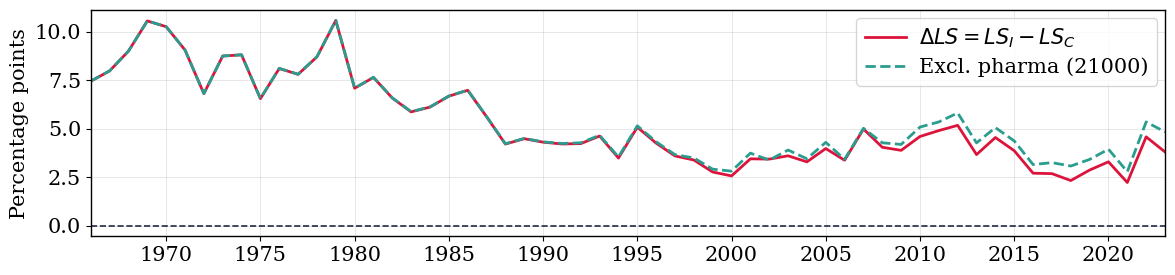

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(12, 3))

ax.plot(df_ts.index, df_ts['LS_I_minus_C'],
        color='crimson', lw=2, label=r'$\Delta LS = LS_I - LS_C$')
ax.plot(df_ts_nopharma.index, df_ts_nopharma['LS_I_minus_C'],
        color='#2A9D8F', lw=2, ls='--', label=r'Excl. pharma (21000)')

ax.axhline(0, color='#1F2A44', linewidth=1.2, ls='--')
ax.set_xlim(df_ts.index.min(), df_ts.index.max())
ax.set_ylabel('Percentage points')
ax.grid(linewidth=0.6, alpha=0.35)
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
ax.legend(loc='upper right')
plt.tight_layout()
# plt.savefig('0_output/LS_pharma_sensitivity.png', dpi=200)
plt.show()